# ML LAB#02 Pandas Library

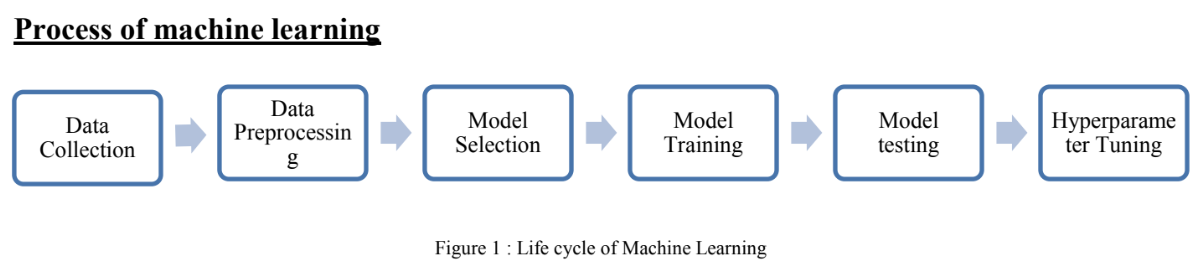

# Series and DataFrame Lecture:

1. What is a Pandas DataFrame?

A DataFrame is a 2D tabular data structure in pandas.
It is similar to an Excel sheet or an SQL table.

2. What is a Pandas Series?

A Series is a one-dimensional labeled array in pandas.
Similar to a column in Excel or a list in Python, but with labels (index).

| Feature        | **Series**                | **DataFrame**               |
| -------------- | ------------------------- | --------------------------- |
| Dimensionality | 1D                        | 2D                          |
| Structure      | Single column             | Table-like                  |
| Index          | Labels                    | Row + Column labels         |
| Missing Values | `fillna()`, `dropna()`    | Same                        |
| Statistics     | `mean()`, `std()`         | Same                        |
| Conversion     | `.tolist()`, `.to_dict()` | `.to_numpy()`, `.to_dict()` |
| Sorting        | `sort_values()`           | Same                        |
| Unique Values  | `unique()`                | `.unique()` on column       |
| Value Counts   | `value_counts()`          | Same on column              |


In [ ]:
import pandas as pd
import numpy as np

data = {
    'Name': ['Ali', 'Sara', 'Omar', 'Zara'],
    'Age': [25, 22, 28, np.nan],
    'Score': [90, 85, np.nan, 95]
}
df = pd.DataFrame(data)
print(df)

df.head(2)    # First 2 rows
df.tail(2)    # Last 2 rows
df.shape      # (rows, columns)
df.info()     # Summary
df.describe() # Statistics summary
df.columns    # Column names
df.index      # Row indexes
# Acessing Data
# By Column
df['Name']
df[['Name', 'Score']]

# By Row
df.loc[1]   # Access by label → row with index 1
df.iloc[1]  # Access by position → row 2

df.loc[0:2, ['Name', 'Age']]  # Specific rows & columns # Rows 0–2, columns Name+Age

# Handling missing values
df.isna().sum()        # Count NaN values per column
df.dropna()            # Drop rows with NaN
df.fillna(0)           # Fill NaN with constant
df['Score'] = df['Score'].fillna(df['Score'].mean())


# Adding and Updating Columns
df['Passed'] = df['Score'] > 80  # Add column
df.loc[2, 'Age'] = 30            # Update specific cell
print(df)

# Deleting Data
# df.drop('Score', axis=1, inplace=True)  # Drop column
# df.drop(2, axis=0, inplace=True)       # Drop row

#Sorting
df.sort_values(by='Age', ascending=True)
df.sort_index()
print(df)

#Statistical Opeartions
df['Age'].mean()
df['Score'].median()
df['Score'].std()

# Grouping and Aggregation
df.groupby('Passed')['Score'].mean()

#Unique and Frequency count
df['Name'].unique()
df['Name'].nunique()
df['Name'].value_counts()

   Name   Age  Score
0   Ali  25.0   90.0
1  Sara  22.0   85.0
2  Omar  28.0    NaN
3  Zara   NaN   95.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    4 non-null      object 
 1   Age     3 non-null      float64
 2   Score   3 non-null      float64
dtypes: float64(2), object(1)
memory usage: 228.0+ bytes
   Name   Age  Score  Passed
0   Ali  25.0   90.0    True
1  Sara  22.0   85.0    True
2  Omar  30.0   90.0    True
3  Zara   NaN   95.0    True
   Name   Age  Score  Passed
0   Ali  25.0   90.0    True
1  Sara  22.0   85.0    True
2  Omar  30.0   90.0    True
3  Zara   NaN   95.0    True


,count
Name,
Ali,1
Sara,1
Omar,1
Zara,1


In [ ]:
import numpy as np
import pandas as pd

# ---------------------------
# 1. Creating a Series
# ---------------------------
print("\n Creating Series from list")
data = [10, 20, 30, 40]
s = pd.Series(data)
print(s)

print("\n Creating Series with custom index")
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print(s)

print("\n Creating Series from dictionary")
data = {'a': 10, 'b': 20, 'c': 30}
s = pd.Series(data)
print(s)

# ---------------------------
# 2. Indexing & Slicing
# ---------------------------
print("\n Accessing single elements")
print("s['a']:", s['a'])      # by label
print("s[1]:", s[1])          # by index

print("\n Slicing Series")
print(s[:2])                  # first 2 elements

# ---------------------------
# 3. Handling Missing Values
# ---------------------------
print("\n Series with missing values")
s = pd.Series([10, np.nan, 30, np.nan, 50])
print(s)

print("\nCheck NaN values:\n", s.isna())
print("\nCount NaN values:\n", s.isna().sum())

print("\nDrop NaN values:\n", s.dropna())

print("\nFill NaN with constant:\n", s.fillna(0))
print("\nFill NaN with mean:\n", s.fillna(s.mean()))
print("\nFill NaN with median:\n", s.fillna(s.median()))
print("\nForward fill:\n", s.fillna(method='ffill'))
print("\nBackward fill:\n", s.fillna(method='bfill'))

# ---------------------------
# 4. Replacing Values
# ---------------------------
print("\n Replace values")
s = s.replace(10, 100)
print(s)

# ---------------------------
# 5. Statistical Operations
# ---------------------------
s2 = pd.Series([10, 20, 30, 40, 50])
print("\n Statistical values")
print("Sum:", s2.sum())
print("Mean:", s2.mean())
print("Median:", s2.median())
print("Max:", s2.max())
print("Min:", s2.min())
print("Standard Deviation:", s2.std())

# ---------------------------
# 6. Conversions
# ---------------------------
print("\n Convert Series to list:", s2.tolist())
print(" Convert Series to dict:", s2.to_dict())
print(" Convert Series to DataFrame:\n", s2.to_frame(name='Values'))

# ---------------------------
# 7. Sorting
# ---------------------------
print("\n Sort by values:\n", s2.sort_values(ascending=False))
print("\n Sort by index:\n", s2.sort_index())

# ---------------------------
# 8. Unique, Count, and Value Counts
# ---------------------------
print("\n Unique values:", s2.unique())
print(" Number of unique values:", s2.nunique())
print(" Frequency count:\n", s2.value_counts())



 Creating Series from list
0    10
1    20
2    30
3    40
dtype: int64

 Creating Series with custom index
a    10
b    20
c    30
dtype: int64

 Creating Series from dictionary
a    10
b    20
c    30
dtype: int64

 Accessing single elements
s['a']: 10
s[1]: 20

 Slicing Series
a    10
b    20
dtype: int64

 Series with missing values
0    10.0
1     NaN
2    30.0
3     NaN
4    50.0
dtype: float64

Check NaN values:
 0    False
1     True
2    False
3     True
4    False
dtype: bool

Count NaN values:
 2

Drop NaN values:
 0    10.0
2    30.0
4    50.0
dtype: float64

Fill NaN with constant:
 0    10.0
1     0.0
2    30.0
3     0.0
4    50.0
dtype: float64

Fill NaN with mean:
 0    10.0
1    30.0
2    30.0
3    30.0
4    50.0
dtype: float64

Fill NaN with median:
 0    10.0
1    30.0
2    30.0
3    30.0
4    50.0
dtype: float64

Forward fill:
 0    10.0
1    10.0
2    30.0
3    30.0
4    50.0
dtype: float64

Backward fill:
 0    10.0
1    30.0
2    30.0
3    50.0
4    50.0
dtype: 

/tmp/ipython-input-1335197761.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("s[1]:", s[1])          # by index
/tmp/ipython-input-1335197761.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print("\nForward fill:\n", s.fillna(method='ffill'))
/tmp/ipython-input-1335197761.py:47: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print("\nBackward fill:\n", s.fillna(method='bfill'))


In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv')

In [ ]:
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
print(df.tail())
# Last 5 rows/records

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
763                     0.171   63        0  
764                     0.340   27        0  
765                     0.245   30        0  
766                     0.349   47        1  
767                     0.315   23        0  


In [ ]:
print(df.shape)
# This (768,9) shows 768 rows and 9 columns
# Columns are called as attributes/features.

(768, 9)


In [ ]:
print(df.info())
# This shows the Datatype of each column/feature/attribute and Non-Null Count
# Non-Null Count = 768 means 768 rows/record are there for that column/feature/attribute

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
print(df.describe())
# This shows the descriptive statistics of each column/feature/attribute such as count(rows), mean, std, min, percentiles etc.

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [ ]:
print(df.columns)
# This shows the columns/features/attributes

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
print(df.isnull().sum())
# 0 means no NULL values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
print(df['Glucose'])
# This will print the record of Glucose column

0      148
1       85
2      183
3       89
4      137
      ... 
763    101
764    122
765    121
766    126
767     93
Name: Glucose, Length: 768, dtype: int64


In [ ]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [ ]:
new_df = df.sort_values('Age',inplace=False)
print(new_df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
736            0      126             86             27      120  27.4   
738            2       99             60             17      160  36.6   
721            1      114             66             36      200  38.1   
60             2       84              0              0        0   0.0   
290            0       78             88             29       40  36.9   
..           ...      ...            ...            ...      ...   ...   
123            5      132             80              0        0  26.8   
684            5      136             82              0        0   0.0   
666            4      145             82             18        0  32.5   
453            2      119              0              0        0  19.6   
459            9      134             74             33       60  25.9   

     DiabetesPedigreeFunction  Age  Outcome  
736                     0.515   21        0  
738                

In [ ]:
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
cdata = df.drop('Outcome',axis=1)
print(cdata)
# axis =1 means drop Column
rdata = df.drop(2,axis=0)
print(rdata)
# axis = 0 means drop row
# drop row of index 2 meaning 3rd row/record

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
# Adding columns
data = df.head(5)
print("\nTaking 5 values from the start from the original dataset df\n")
print(data)
names = ['a','b','c','d','e']
data['names'] = names
print("\nAdding column directly\n")
print(data)
# or another way to do it is
print("\nUsing .insert to add column and its values\n")
data.insert(0,'name',names)
print(data)


Taking 5 values from the start from the original dataset df

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Adding column directly

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   


/tmp/ipython-input-1053080454.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['names'] = names


When you set ignore_index=True, it resets the index of the resulting DataFrame after combining or appending, so that the new DataFrame has a continuous, sequential index starting from 0.   

| **Setting**                      | **Effect**                                                |
| -------------------------------- | --------------------------------------------------------- |
| `ignore_index=False` *(default)* | Keeps existing indices, may lead to **duplicate indices** |
| `ignore_index=True`              | Resets index, makes it **sequential and clean**           |


In [ ]:
# Adding new row
print(df.columns)
# Taking 10 values from head
print(df.head(10))
# Why append() fails
# df.append() is deprecated since pandas 1.4.0.
# It was removed in pandas 2.0.
# Now, the recommended approach is to use pd.concat().
new_row = {'Pregnancies':2,'Glucose':190,'BloodPressure':72,'SkinThickness':35,'Insulin':0,'BMI':33.6,'DiabetesPedigreeFunction':0.627,'Age':50,'Outcome':1}
data_ = df.head(10)
data_ = pd.concat([data_,pd.DataFrame([new_row])], ignore_index=True)
print("\nAdding new row\n")
print(data_)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0 

In [ ]:
# Extracting columns
print(df[['Age','Pregnancies']])
y=df['Outcome']
print(y)

     Age  Pregnancies
0     50            6
1     31            1
2     32            8
3     21            1
4     33            0
..   ...          ...
763   63           10
764   27            2
765   30            5
766   47            1
767   23            1

[768 rows x 2 columns]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Loc method is used to extract rows and columns using their names. Whereas iloc
method extract data based on integer or indexing of row and columns. Pop method extract desired column by
removing it from original dataset and storing into another location.

In [ ]:
print(df.loc[0:6,'Age'])
# This means this extracts data of column Age from index 0 to 6th index meaning 1st record to 7th record

0    50
1    31
2    32
3    21
4    33
5    30
6    26
Name: Age, dtype: int64


In [ ]:
print(df.iloc[0:6, 0:5])
# 0th index to 5th index (6th index is not included)
# 0:5 shows that for the first 5 columns show data from 0th index to 5th index

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin
0            6      148             72             35        0
1            1       85             66             29        0
2            8      183             64              0        0
3            1       89             66             23       94
4            0      137             40             35      168
5            5      116             74              0        0


In [ ]:
# new_df.pop('Outcome') removes the Outcome column from new_df and returns it as a Series.
# Since you're assigning the result of .pop() outcome, the DataFrame gets replaced by a Series.
# So after this line, outcome is now just a Series containing the Outcome values:
new_df = df.head(5)
print(new_df)
outcome = new_df.pop('Outcome')
print(outcome)
print(list(outcome))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64
[1, 0, 1, 0, 1]


| **Code**                                   | **Effect**                                             |
| ------------------------------------------ | ------------------------------------------------------ |
| `df = df.reset_index(drop=False)`          | Creates a **new DataFrame** with old index as a column |
| `df.reset_index(drop=False, inplace=True)` | Modifies `df` directly; **no reassignment** needed     |


In [ ]:
# resetting and setting index
df = pd.read_csv('/content/diabetes.csv')
df.reset_index(drop=False,inplace=True)
print(df)

# setting the index:
df.set_index('Pregnancies',inplace=True)
print(df)
# set_index('Pregnancies') makes the column Pregnancies the new index of your DataFrame.
# inplace=True → modifies the DataFrame directly and does not return anything.
# After this, the old default index (0,1,2,3,...) is replaced by the values from the Pregnancies column.
# The Pregnancies column will no longer appear as a column — it becomes the index.

     index  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0        0            6      148             72             35        0  33.6   
1        1            1       85             66             29        0  26.6   
2        2            8      183             64              0        0  23.3   
3        3            1       89             66             23       94  28.1   
4        4            0      137             40             35      168  43.1   
..     ...          ...      ...            ...            ...      ...   ...   
763    763           10      101             76             48      180  32.9   
764    764            2      122             70             27        0  36.8   
765    765            5      121             72             23      112  26.2   
766    766            1      126             60              0        0  30.1   
767    767            1       93             70             31        0  30.4   

     DiabetesPedigreeFuncti

**Changing values of records at particular column:**   


In [ ]:
# # Update sex column
# df.loc[df['sex'] == 0, 'sex'] = 'female'
# df.loc[df['sex'] == 1, 'sex'] = 'male'

# Update Glucose column
df.loc[df['Glucose'] == 0, 'Glucose'] = 1
print(df)

# or other way to do is:
df['Glucose'][df['Glucose'] ==0] = 1

# or other way is using .replace
df['Glucose'].replace(0,1,inplace=True)

             index Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
Pregnancies                                                               
6                0     148             72             35        0  33.6   
1                1      85             66             29        0  26.6   
8                2     183             64              0        0  23.3   
1                3      89             66             23       94  28.1   
0                4     137             40             35      168  43.1   
...            ...     ...            ...            ...      ...   ...   
10             763     101             76             48      180  32.9   
2              764     122             70             27        0  36.8   
5              765     121             72             23      112  26.2   
1              766     126             60              0        0  30.1   
1              767      93             70             31        0  30.4   

             DiabetesPed

/tmp/ipython-input-3621177578.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Glucose'][df['Glucose'] ==0] = 1
/tmp/ipython-input-3621177578.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [ ]:
# Using map
data =pd.DataFrame({'sex': [1,0]})
print(data)
data['sex'] = data['sex'].map({0: 'female', 1: 'male'})
print(data)

   sex
0    1
1    0
      sex
0    male
1  female


In [ ]:
import pandas as pd

# Create a Series of numeric values
data = pd.Series([0, 1])

# Map directly on the Series
data = data.map({0: 'female', 1: 'male'})

print(data)

0    female
1      male
dtype: object


In [ ]:
import pandas as pd

# Create a sample DataFrame
data = pd.DataFrame({
    'sex': [0, 1, 1, 0, 1],
    'slope': [0, 1, 2, 1, 0],
    'age': [25, 35, 45, 55, 65]
})

print("Original DataFrame:")
print(data)

data.loc[data['sex'] == 0, 'sex'] = 'female'
data.loc[data['sex'] == 1, 'sex'] = 'male'

# Update slope column
data.loc[data['slope'] == 0, 'slope'] = 'upsloping'
data.loc[data['slope'] == 1, 'slope'] = 'flat'
data.loc[data['slope'] == 2, 'slope'] = 'downsloping'

print("\nAfter Replacement using .loc[]:")
print(data)

data['sex'] = data['sex'].replace({0: 'female', 1: 'male'})
data['slope'] = data['slope'].replace({
    0: 'upsloping',
    1: 'flat',
    2: 'downsloping'
})

print("\nAfter Replacement using .replace():")
print(data)

data['sex'] = data['sex'].map({0: 'female', 1: 'male'})
print("\nAfter Replacement using .map():")
print(data)

Original DataFrame:
   sex  slope  age
0    0      0   25
1    1      1   35
2    1      2   45
3    0      1   55
4    1      0   65

After Replacement using .loc[]:
      sex        slope  age
0  female    upsloping   25
1    male         flat   35
2    male  downsloping   45
3  female         flat   55
4    male    upsloping   65

After Replacement using .replace():
      sex        slope  age
0  female    upsloping   25
1    male         flat   35
2    male  downsloping   45
3  female         flat   55
4    male    upsloping   65

After Replacement using .map():
   sex        slope  age
0  NaN    upsloping   25
1  NaN         flat   35
2  NaN  downsloping   45
3  NaN         flat   55
4  NaN    upsloping   65


/tmp/ipython-input-3273599211.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'female' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['sex'] == 0, 'sex'] = 'female'
/tmp/ipython-input-3273599211.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'upsloping' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['slope'] == 0, 'slope'] = 'upsloping'


| Feature         | **`.loc[]`**                | **`.replace()`**          |
| --------------- | --------------------------- | ------------------------- |
| **Best for**    | Conditional replacement     | Direct mapping of values  |
| **Code length** | Longer                      | Shorter & cleaner         |
| **Performance** | Slower for large DataFrames | Faster for mapping        |
| **Flexibility** | Can use complex conditions  | Simple value mapping only |


**Data Visualization:**

A bar chart is used to display categorical data using rectangular bars. Each bar represents a category, and the
length or height of the bar corresponds to the value or frequency of that category. Bar charts are effective for
comparing values between different categories. Whereas a histogram is used to visualize the distribution of
continuous data. It divides the data into intervals, known as bins, and then counts how many data points fall into
each bin. The height of each bar represents the frequency or relative frequency of data points in that bin.   

Histograms help you understand the shape and spread of the data. A scatter plot is used to show the relationship
between two variables. Each data point is represented as a point on the chart, with one variable plotted along the
x-axis and the other along the y-axis. Scatter plots help identify correlations, clusters, and outliers in data. A box
plot is used to display the distribution of a dataset through its five-number summary: minimum, first quartile
(Q1), median, third quartile (Q3), and maximum. The plot consists of a box that represents the interquartile range
(IQR) and "whiskers" that extend to the minimum and maximum values within a certain range. Box plots are
useful for visualizing data spread and identifying outliers.

(array([300., 157.,  92.,  86.,  52.,  34.,  26.,  16.,   4.,   1.]),
 array([21., 27., 33., 39., 45., 51., 57., 63., 69., 75., 81.]),
 <BarContainer object of 10 artists>)

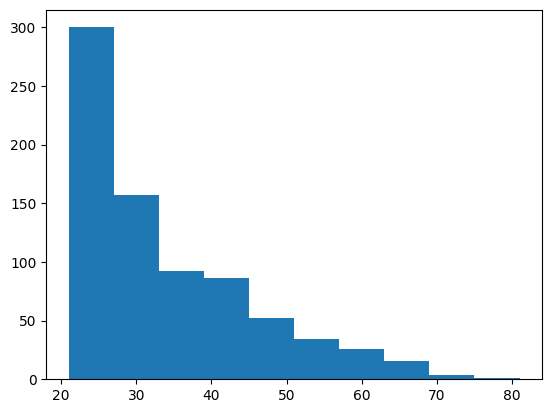

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['Age'])

Text(0, 0.5, 'Outcome')

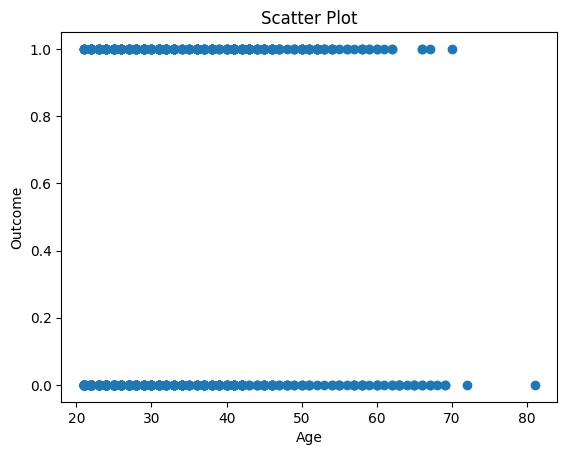

In [ ]:
import seaborn as sns
x1 = df['Age']
x2 = df['Outcome']
plt.scatter(x1,x2)
plt.title("Scatter Plot")
plt.xlabel("Age")
plt.ylabel("Outcome")

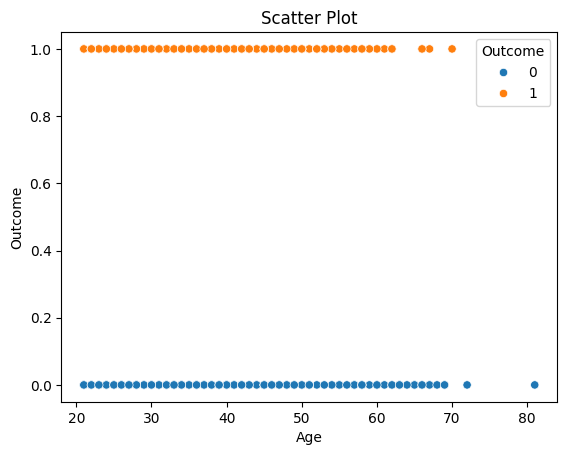

In [ ]:
import seaborn as sns
x1 = df['Age']
x2 = df['Outcome']
sns.scatterplot(x=x1,y=x2,hue=df['Outcome'])
# hue = df['Outcome] means different colors for outcomes
plt.title("Scatter Plot")
plt.xlabel("Age")
plt.ylabel("Outcome")
plt.show()

/tmp/ipython-input-3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

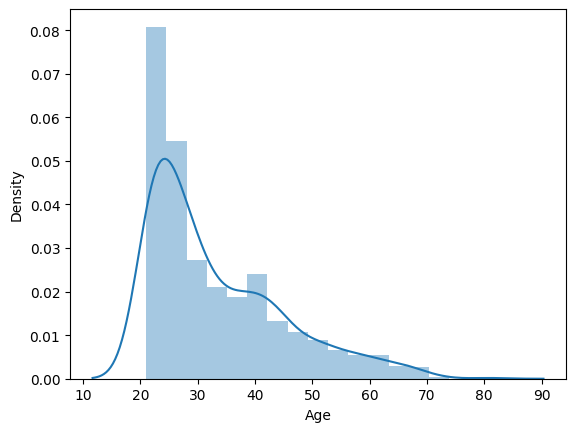

In [ ]:
sns.distplot(df['Age'])

In [ ]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


<Axes: ylabel='Glucose'>

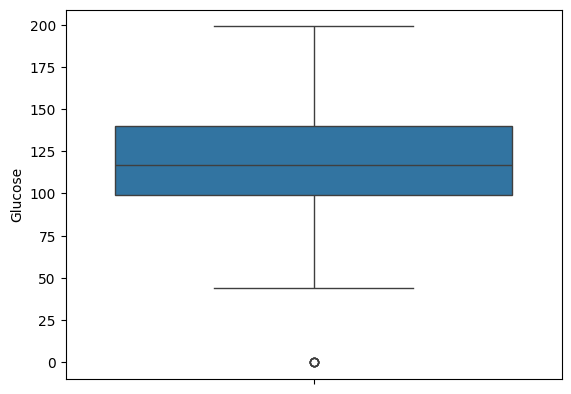

In [ ]:
sns.boxplot(df['Glucose'])

df.corr()

Calculates the correlation matrix of all numerical columns.

Each value ranges between -1 and 1:

1 → Perfect positive correlation

-1 → Perfect negative correlation

0 → No correlation

2. annot=True

Displays the actual correlation values on each cell.

3. plt.figure(figsize=(14, 14))

Must be called before sns.heatmap() to control the size of the entire figure.

<Figure size 1400x1400 with 0 Axes>

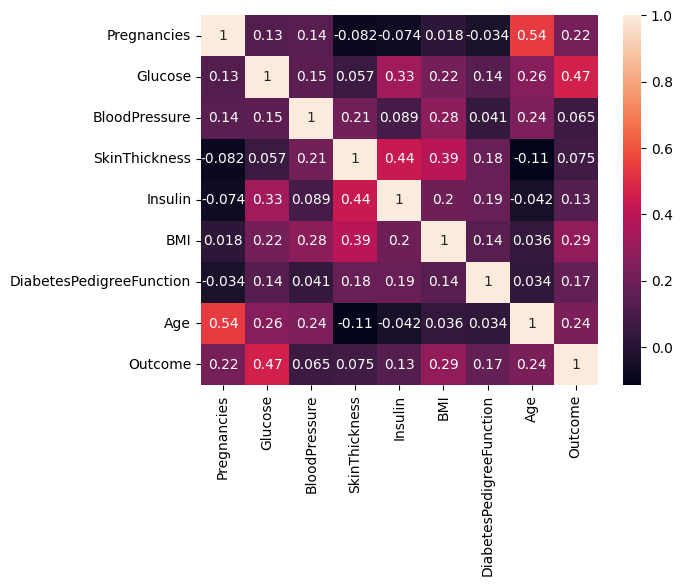

<Figure size 1400x1400 with 0 Axes>

In [ ]:
# Correlation plot
sns.heatmap(data=df.corr(),annot=True)
plt.figure(figsize=(14,14))
# df.corr()
# Calculates the correlation matrix of all numerical columns.
# Each value ranges between -1 and 1:
# 1 → Perfect positive correlation
# -1 → Perfect negative correlation
# 0 → No correlation
# 2. annot=True
# Displays the actual correlation values on each cell.
# 3. plt.figure(figsize=(14, 14))
# Must be called before sns.heatmap() to control the size of the entire figure.

For a dataset:

Q1 (25th percentile): Value below which 25% of the data lies.

Q2 (50th percentile / Median): Value below which 50% of the data lies.

Q3 (75th percentile): Value below which 75% of the data lies.

IQR (Interquartile Range):

IQR=Q3−Q1

Outlier criteria (Tukey's method):

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Any data point < Lower Bound or > Upper Bound is considered an outlier.

**Finding Quartiles:**


In [ ]:
import pandas as pd
col = "Glucose"
Q1 = df[col].quantile(0.25)
Q2 = df[col].quantile(0.5)
Q3 = df[col].quantile(0.75)
print(Q1,Q2,Q3)

print("Q1 (25th percentile):", Q1)
print("Q2 (Median / 50th percentile):", Q2)
print("Q3 (75th percentile):", Q3)

99.0 117.0 140.25
Q1 (25th percentile): 99.0
Q2 (Median / 50th percentile): 117.0
Q3 (75th percentile): 140.25


Calculate IQR and Find Outliers:
IQR = Q3 - Q1

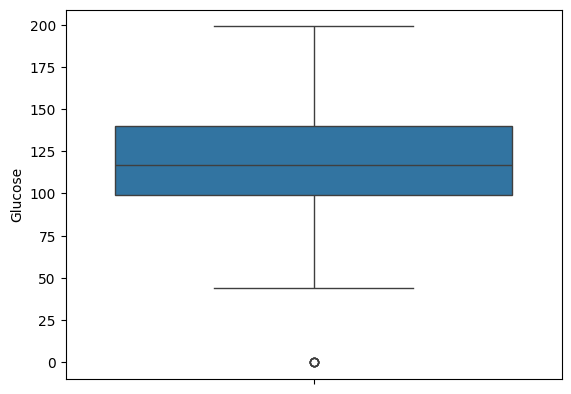

Lower Bound: 37.125
Upper Bound: 202.125
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
75             1        0             48             20        0  24.7   
182            1        0             74             20       23  27.7   
342            1        0             68             35        0  32.0   
349            5        0             80             32        0  41.0   
502            6        0             68             41        0  39.0   

     DiabetesPedigreeFunction  Age  Outcome  
75                      0.140   22        0  
182                     0.299   21        0  
342                     0.389   22        0  
349                     0.346   37        1  
502                     0.727   41        1  


In [ ]:
col = 'Glucose'
Q1 = df[col].quantile(0.25)
Q2 = df[col].quantile(0.5)
Q3 = df[col].quantile(0.75)

import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df[col])
plt.show()

IQR = Q3 - Q1
# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
print(outliers)